In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import torch
import torch.nn as nn
import os
import numpy as np

os.chdir("/Users/shanewarland/Desktop/transformer-from-scratch/notebooks")
os.getcwd()

'/Users/shanewarland/Desktop/transformer-from-scratch/notebooks'

In [9]:
rng = np.random.default_rng(seed=42) 
Q = rng.random(size=(4, 8))
K = rng.random(size=(4, 8))
V = rng.random(size=(4, 8))

In [12]:
L = 4
D = 8
position = torch.arange(L, dtype=torch.float32).unsqueeze(1)

even_dims = torch.arange(0,D,2, dtype=torch.float32)

denominator = 10000 ** (even_dims / D)

angles = position / denominator


PE = torch.zeros(L, D)
position = torch.arange(L, dtype=torch.float32).unsqueeze(1)
denominator = 10000 ** (even_dims / D)
angles = position / denominator

PE[:, 0::2] = torch.sin(angles)
PE[:, 1::2] = torch.cos(angles)
PE

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])

In [13]:
import torch
import torch.nn as nn
from src.attention import MultiHeadSelfAttention
from src.transformer_encoder import TransformerEncoderBlock
from src.transformer_encoder import TransformerEncoder

DNA_VOCAB = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4}
test = 'ACGtN'
def tokenize_dna(sequence):
    sequence = sequence.upper()
    sequence_tokens = [DNA_VOCAB[nucleotide] for nucleotide in sequence]
    return sequence_tokens


tokenize_dna(test)
len(test)

5

In [14]:
import torch.nn as nn
from src.dna_transformer import DNATransformer

X = torch.randint(0, 5, (3, 10))
model = DNATransformer(vocab_size=5,d_model=8,num_heads=2,d_ff=32,num_layers=3,max_len=100)
logits, layer_weights = model(X)
assert all([layer.shape == (3, 2, 10, 10) for layer in layer_weights]), 'layer_weights shape malformed'

In [15]:
from src.dataset import DNADataset
from torch.utils.data import DataLoader
sequences = ['ACGT', 'AACC', 'ATCC', 'AGAG']
labels = [0,1,0,1]
dataset = DNADataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
X, y = next(iter(dataloader))
print(X.shape)
print(y.shape)

torch.Size([2, 4])
torch.Size([2, 1])


In [16]:
import torch
import torch.nn as nn

from src.positional_encoding import PositionalEncoding
from src.transformer_encoder import TransformerEncoder
from src.dna_transformer import DNATransformer

model = DNATransformer(vocab_size=5,d_model=8,num_heads=2,d_ff=32,num_layers=3,max_len=100)
logits, layer_weights = model(X)

In [17]:
criterion = torch.nn.BCEWithLogitsLoss()
loss = criterion(logits, y)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
loss.backward()
optimizer.step()
print(logits.shape)
print(y.shape)
print(loss)
print(model.classifier.weight.grad)
print(model.classifier.weight.grad.shape)

torch.Size([2, 1])
torch.Size([2, 1])
tensor(0.2927, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor([[ 0.3044, -0.1335,  0.0107,  0.2368, -0.1242,  0.1719, -0.1286, -0.3375]])
torch.Size([1, 8])


In [19]:
from src.dataset import DNADataset
from torch.utils.data import DataLoader
sequences = ['ACGT', 'AACC', 'ATCC', 'AGAG']
labels = [0,1,0,1]
dataset = DNADataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
model = DNATransformer(vocab_size=5,d_model=8,num_heads=2,d_ff=32,num_layers=3,max_len=100)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
epochs = 10

for epoch in range(epochs):
    model.train()  
    running_train_loss = 0.0

    for X, y in dataloader:
        
        optimizer.zero_grad()
        logits, _ = model(X)
        

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        print(loss.item())
        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(dataloader)
    print('epoch num:', epoch, epoch_train_loss)


  

0.9140751361846924
0.6121380925178528
epoch num: 0 0.7631066143512726
0.6093473434448242
0.8602588176727295
epoch num: 1 0.7348030805587769
0.7391386032104492
0.7005397081375122
epoch num: 2 0.7198391556739807
0.7477544546127319
0.674606204032898
epoch num: 3 0.7111803293228149
0.5929331183433533
0.8053877949714661
epoch num: 4 0.6991604566574097
0.6751257181167603
0.7011127471923828
epoch num: 5 0.6881192326545715
0.6739605665206909
0.6857942342758179
epoch num: 6 0.6798774003982544
0.6747438907623291
0.6704825162887573
epoch num: 7 0.6726132035255432
0.7350422143936157
0.6065458655357361
epoch num: 8 0.6707940399646759
0.6068848967552185
0.7102286219596863
epoch num: 9 0.6585567593574524


In [20]:
import random
def generate_synthetic_dna_no_motif(n_sequences, seq_len, motif):
    sequence_list = []
    bases = ['A', 'C', 'G', 'T']
    for i in range(int(n_sequences/2)):
        while True:
            seq = ''.join(random.choices(bases, k=seq_len))
            if motif not in seq:
                sequence_list.append(seq)
                break
    return sequence_list


def generate_synthetic_dna_with_motif(n_sequences, seq_len, motif):
    sequence_list = []
    bases = ['A', 'C', 'G', 'T']
    for i in range(int(n_sequences/2)):
        remaining_length = seq_len - len(motif)
        
        background = ''.join(random.choices(bases, k=remaining_length))

        insert_pos = random.randint(0, remaining_length)

        motif_dna = background[:insert_pos] + motif + background[insert_pos:]
        sequence_list.append(motif_dna)
    return sequence_list
    
    
def create_combined_dataset(negatives, positives):
    combined = negatives + positives
    labels = ([0] * len(negatives)) + ([1] * len(positives))
    paired = list(zip(combined, labels))
    random.shuffle(paired)
    combined, labels = map(list, zip(*paired))
    return combined, labels

In [21]:
negatives = generate_synthetic_dna_no_motif(1000, 100, "TATAAA")
positives = generate_synthetic_dna_with_motif(1000, 100, "TATAAA")
sequences, labels = create_combined_dataset(negatives, positives)
assert len(sequences) == 1000
assert len(labels) == 1000
assert sum(labels) == 500

for seq, label in zip(sequences, labels):
    if label == 0:
        assert "TATAAA" not in seq
    else:
        assert "TATAAA" in seq

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(sequences, labels, test_size = 0.2, stratify = labels, random_state = 42)

train_dataset = DNADataset(X_train, y_train)
val_dataset = DNADataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [38]:

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
epochs = 10
history = {
        "train_loss": [],
        "validation_loss": [],
    }

for epoch in range(epochs):
    model.train()  
    running_train_loss = 0.0

    for X, y in train_loader:
        
        optimizer.zero_grad()
        logits, _ = model(X)
        

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()


        ## now for evaluation
    model.eval()
    ## Initialize variables
    running_val_loss = 0.0
    ## No longer update gradients
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in val_loader:
            
            ## Get predictions
            logits, _ = model(X)
            ## Calculate Loss
            loss = criterion(logits, y)
            running_val_loss += loss.item()

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5)

            if predictions == y: correct += 1
            total += 1



    epoch_val_loss = running_val_loss / len(val_loader)
    history["validation_loss"].append(epoch_val_loss)
    validation_accuracy = correct/total

    epoch_train_loss = running_train_loss / len(train_loader)
    history["train_loss"].append(epoch_train_loss)
    print('epoch num:', epoch, epoch_train_loss)
    print('validation_accuracy:', validation_accuracy)


RuntimeError: Boolean value of Tensor with more than one value is ambiguous

<positron-console-cell-35>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


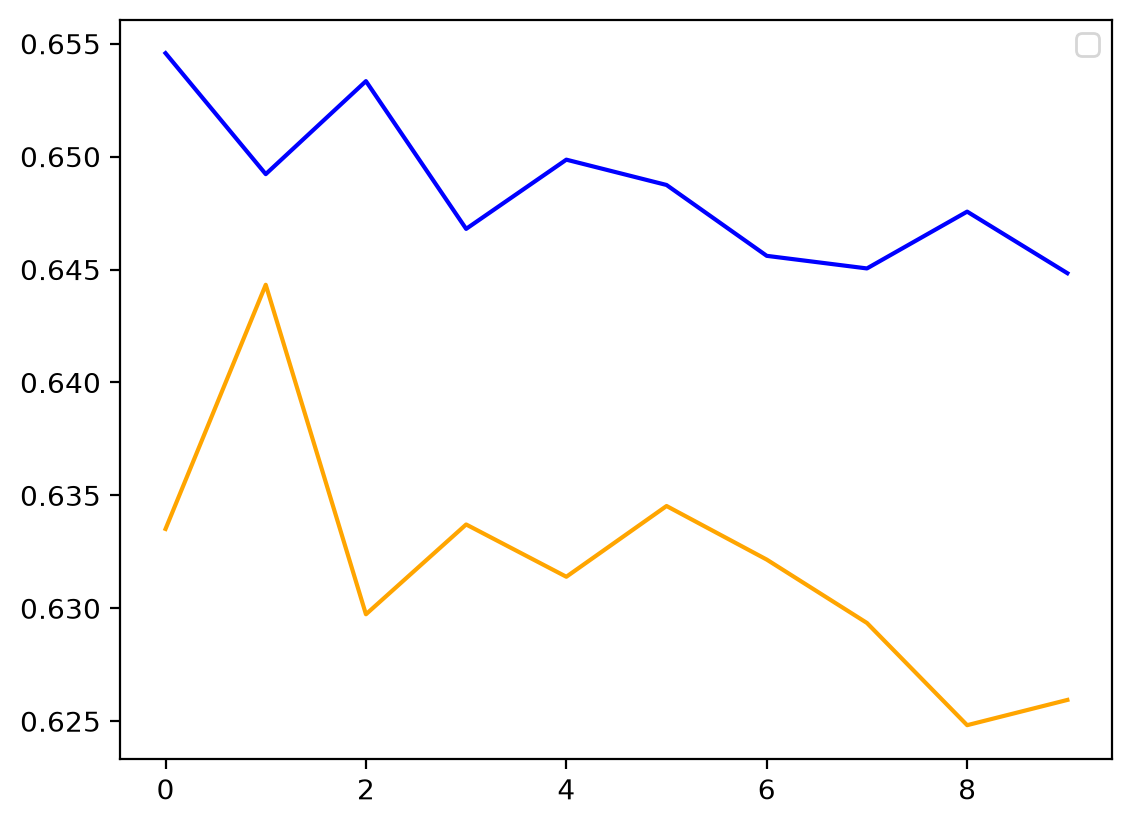

In [35]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], color = 'blue')
plt.plot(history['validation_loss'], color = 'orange')
plt.legend()